In [1]:
# =================================================================
# STEP 1: LIBRARY IMPORTS
# Importing tools for matrix operations and similarity calculations.
# =================================================================

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print("Libraries for Recommendation System loaded.")

Libraries for Recommendation System loaded.


In [2]:
# =================================================================
# STEP 2: DATASET LOADING
# SOURCE: MovieLens Small Dataset.
# GOAL: Create a pivot table where rows are users and columns are movies.
# =================================================================

# Creating a sample dataset for demonstration
data = {
    'user_id': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'movie': ['The Matrix', 'Inception', 'Interstellar',
              'The Matrix', 'Inception', 'Toy Story',
              'The Dark Knight', 'Interstellar', 'Inception',
              'Toy Story', 'Shrek', 'The Matrix',
              'The Dark Knight', 'Interstellar'],
    'rating': [5, 4, 5, 5, 5, 2, 4, 5, 4, 5, 4, 3, 5, 4]
}

df = pd.DataFrame(data)

# Create User-Item Matrix
user_item_matrix = df.pivot_table(index='user_id', columns='movie', values='rating').fillna(0)

print("User-Item Matrix created:")
print(user_item_matrix)

User-Item Matrix created:
movie    Inception  Interstellar  Shrek  The Dark Knight  The Matrix  \
user_id                                                                
1              4.0           5.0    0.0              0.0         5.0   
2              5.0           0.0    0.0              0.0         5.0   
3              4.0           5.0    0.0              4.0         0.0   
4              0.0           0.0    4.0              0.0         3.0   
5              0.0           4.0    0.0              5.0         0.0   

movie    Toy Story  
user_id             
1              0.0  
2              2.0  
3              0.0  
4              5.0  
5              0.0  


In [3]:
# =================================================================
# STEP 3: COLLABORATIVE FILTERING (SIMILARITY CALCULATION)
# Using Cosine Similarity to identify users with similar rating patterns.
# =================================================================

# Calculate User Similarity Matrix
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

def get_recommendations(user_id, num_recommendations=2):
    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False).index[1:]

    # Get movies rated by similar users but not by the target user
    user_rated_movies = user_item_matrix.loc[user_id]
    unrated_movies = user_rated_movies[user_rated_movies == 0].index

    recommendations = user_item_matrix.loc[similar_users, unrated_movies].mean().sort_values(ascending=False)
    return recommendations.head(num_recommendations)

# Example: Get recommendations for User 1
print("\nRecommendations for User 1:")
print(get_recommendations(user_id=1))


Recommendations for User 1:
movie
The Dark Knight    2.25
Toy Story          1.75
dtype: float64


--- Evaluation Result ---
Model RMSE: 1.2349


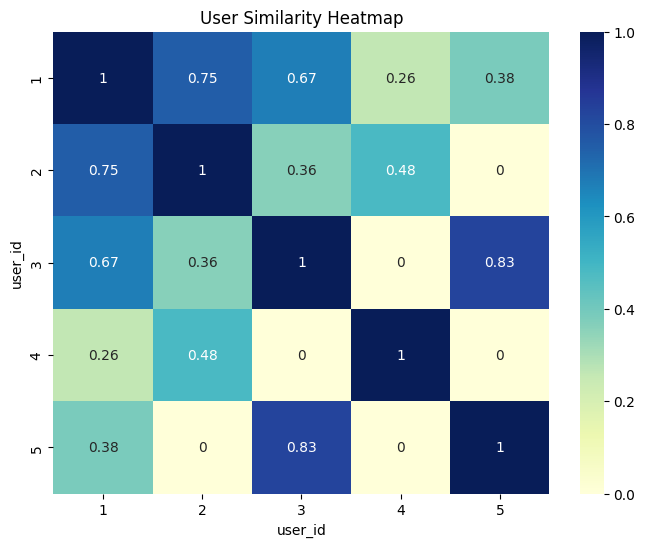

In [4]:
# =================================================================
# STEP 4: EVALUATION METRICS
# Calculating Root Mean Squared Error (RMSE) to evaluate prediction quality.
# =================================================================

# Simple evaluation by comparing actual vs predicted values for existing ratings
def calculate_rmse(matrix, similarity):
    pred = similarity.dot(matrix) / np.array([np.abs(similarity).sum(axis=1)]).T
    actual = matrix.values[matrix.values.nonzero()]
    prediction = pred[matrix.values.nonzero()]
    return np.sqrt(mean_squared_error(actual, prediction))

rmse = calculate_rmse(user_item_matrix, user_similarity)
print(f"--- Evaluation Result ---")
print(f"Model RMSE: {rmse:.4f}")

# Visualize the Similarity Heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(user_similarity_df, annot=True, cmap='YlGnBu')
plt.title('User Similarity Heatmap')
plt.show()